# Imports

In [117]:
import math
import itertools

import numpy as np
import cupy as cp
import numba as nb
import numba.cuda
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy.ndimage
import rasterio
import PIL
import sklearn.linear_model

In [118]:
default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

<br><br><br><br><br>

# Let's make some kernels!

The conventional gully-finding technique, called Difference From Mean Elevation (DFME), is to subtract the elevation of a point from the mean, neighboring elevations.

It is described in Martin Evans's and John Lindsay's "High resolution quantification of gully erosion in upland peatlands at the landscale scale", _Earth Surf. Process Landforms_ **35**, 876-886 (2010), as well as other papers that cite Evans & Lindsay. From the text:

> DFME is equivalent to a high-pass filter in the field of image processing and can be calculated using most standard GISs and image processing software.

In fact, it's a convolution of the image with a kernel that looks like the following. (Evans & Lindsay describe both square and circular windows for computing the mean regional elevation. A square window can be faster to calculate, not as a convolution, by taking advantage of cumulative sums. However, a circular window is more natural and isn't any slower to calculate if we use the convolution technique.)

In [3]:
def point_in_disk(radius=50, linewidth=1):
    width = 2 * radius + 1
    bigx, bigy = np.meshgrid(np.arange(10 * width), np.arange(10 * width))
    x = bigx / 10 - radius - 0.5
    y = bigy / 10 - radius - 0.5
    disk = x**2 + y**2 <= radius**2
    minidisk = x**2 + y**2 <= linewidth**2
    small_disk = np.sum(np.sum(disk.reshape((width, 10, width, 10)), axis=-1), axis=-2)
    small_minidisk = np.sum(np.sum(minidisk.reshape((width, 10, width, 10)), axis=-1), axis=-2)
    small_disk[small_minidisk > 0] = 0
    small_disk = -small_disk / np.sum(small_disk)
    small_disk[small_minidisk > 0] = 1 / np.sum(small_minidisk > 0)
    return small_disk

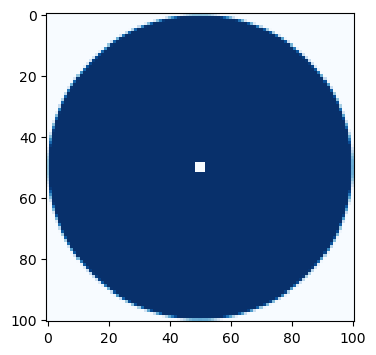

In [4]:
fig, ax = plt.subplots(figsize=(4, 4))

tmp = point_in_disk()
ax.imshow(tmp, vmin=np.nanmin(tmp), vmax=0, cmap="Blues_r")

None

Gullies are elongated troughs, so we should be able to do better by creating convolution kernels that have this shape. (See convolution kernels for edge detection.)

Rather than having just two parameters, the disk `radius` and point `linewidth`, we have a third: the length of the trough. The following function produces a line with a Gaussian fall-off, but a sharp fall-off would work as well. `linelength` is the σ parameter of the Gaussian, so 95% of the line is within `4 * linewidth`.

In [5]:
def line_in_disk(angle, radius=50, linelength=15, linewidth=1):
    width = 2 * radius + 1
    bigx, bigy = np.meshgrid(np.arange(10 * width), np.arange(10 * width))
    x = bigx / 10 - radius - 0.5
    y = bigy / 10 - radius - 0.5
    disk = x**2 + y**2 <= radius**2
    minidisk = np.exp(-(x**2 + y**2) / 2 / linelength**2) / np.sqrt(2 * np.pi * linelength**2)
    line = np.abs(x * np.sin(-angle * np.pi/180) - y * np.cos(angle * np.pi/180)) < linewidth
    centerline = minidisk * (disk & line)
    big = -(disk / np.sum(disk)) + (centerline / np.sum(centerline))
    small = np.sum(np.sum(big.reshape((width, 10, width, 10)), axis=-1), axis=-2)
    return small

3.608224830031759e-16


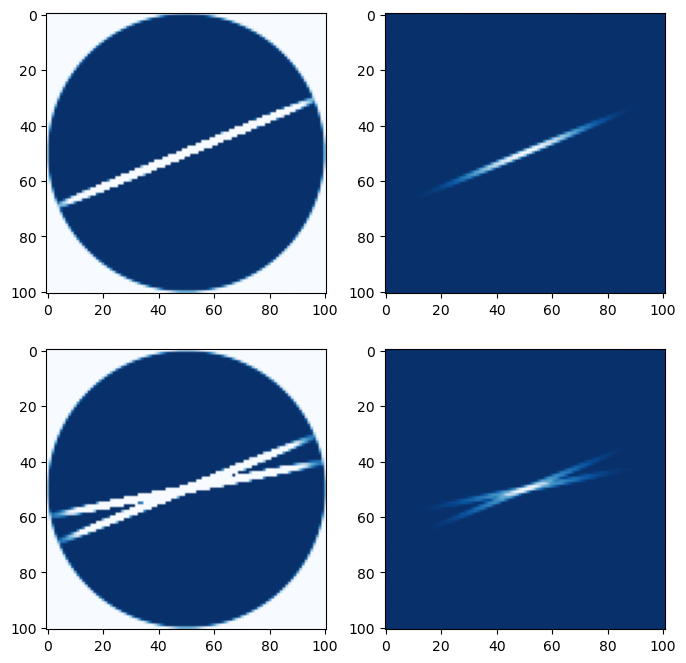

In [6]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(8, 8))

tmp = line_in_disk(22.5)
tmp2 = line_in_disk(11.25)
print(np.sum(tmp))

ax1.imshow(tmp, vmin=np.nanmin(tmp), vmax=0, cmap="Blues_r")
ax2.imshow(tmp, vmin=0, vmax=np.nanmax(tmp), cmap="Blues_r")
ax3.imshow(tmp + tmp2, vmin=np.nanmin(tmp + tmp2), vmax=0, cmap="Blues_r")
ax4.imshow(tmp + tmp2, vmin=0, vmax=np.nanmax(tmp + tmp2), cmap="Blues_r")

None

In [154]:
def half_disk(angle, radius=50, linelength=15):
    width = 2 * radius + 1
    bigx, bigy = np.meshgrid(np.arange(10 * width), np.arange(10 * width))
    x = bigx / 10 - radius - 0.5
    y = bigy / 10 - radius - 0.5
    disk = np.exp(-(x**2 + y**2) / 2 / linelength**2) / np.sqrt(2 * np.pi * linelength**2)
    line = x * np.sin(-angle * np.pi/180) - y * np.cos(angle * np.pi/180) < 0
    positive = disk * line
    negative = disk * ~line
    big = positive / np.sum(positive) - negative / np.sum(negative)
    small = np.sum(np.sum(big.reshape((width, 10, width, 10)), axis=-1), axis=-2)
    return small

-1.1102230246251565e-16 0.9871252261232507


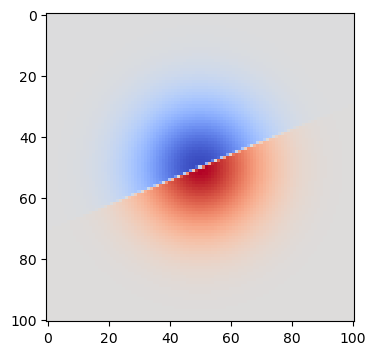

In [155]:
fig, ax = plt.subplots(figsize=(4, 4))

tmp = half_disk(22.5)
print(np.sum(tmp), np.sum(tmp * (tmp > 0)))
ax.imshow(tmp, vmin=-np.nanmax(tmp), vmax=np.nanmax(tmp), cmap="coolwarm")

None

<br><br><br><br><br>

# Sample data

This is a 0.01×0.01 degree square of Sonoma County that includes the OAEC site.

The red rectangle defining `small_image` is a gully that Brock is currently investigating.

In [7]:
with rasterio.open("../data/Sonoma_DTM_2022-OAEC-0.01-degree.tif") as file:
    elevation = file.read(1)
    transform = file.transform
    crs = file.crs

In [8]:
small_image = elevation[1800:2900, 600:1500]

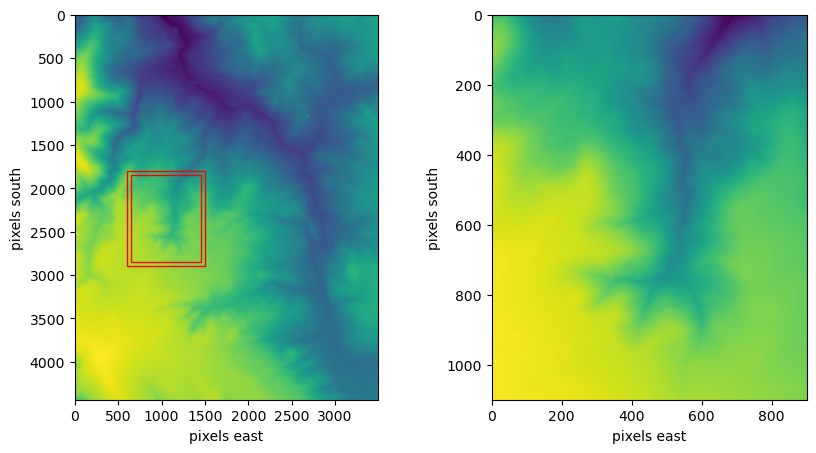

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.imshow(elevation)
ax1.add_patch(mpl.patches.Rectangle((600, 1800), 1500 - 600, 2900 - 1800, edgecolor="red", facecolor="none"))
ax1.add_patch(mpl.patches.Rectangle((600 + 50, 1800 + 50), 1500 - 600 - 100, 2900 - 1800 - 100, edgecolor="red", facecolor="none"))

ax1.set_xlabel("pixels east")
ax1.set_ylabel("pixels south")

ax2.imshow(small_image)

ax2.set_xlabel("pixels east")
ax2.set_ylabel("pixels south")

None

<br><br><br><br><br>

# Compute convolutions

Both `scipy.signal.convolve2d` and `jax.scipy.signal.convolve2d` are too slow: SciPy's because it is single-threaded on a CPU, and JAX's because they're attempting some optimization that relies on small kernels, and our kernels are much larger than theirs. (In previous studies, I found a 50 meter radius to be better than any smaller windows for calculating regional elevation.)

I wrote a CUDA kernel in Numba to compute convolutions with reflecting (minimally problematic) boundary conditions. It can be converted to run on CPUs with minimal changes, though 1 GeForce RTX 3060 is 5× as fast as 16 AMD Ryzen 7 5700G running in parallel.

This CUDA kernel computes convolutions for 16 convolution kernels (with different angles) at once. It doesn't need to: launching 16 CUDA kernels is just as fast. Changing the order of the "angles" dimension with respect to $x$ and $y$ in the array or in the CUDA grid doesn't change the computation time, either.

In [10]:
_convolve2dkernel = {}

def convolve2d(image, multikernel):
    image = cp.asarray(image, dtype=np.float32)
    multikernel = cp.asarray(multikernel, dtype=np.float32)
    output = cp.zeros(multikernel.shape[:1] + image.shape, image.dtype)

    key = (image.shape, multikernel.shape)
    if key not in _convolve2dkernel:
        imageI, imageJ = image.shape
        kernelI, kernelJ = multikernel.shape[1:]
        num_angles = multikernel.shape[0]

        @nb.cuda.jit
        def fcn(image, multikernel, output):
            ang, imi, imj = nb.cuda.grid(3)
            if imi >= imageI or imj >= imageJ:
                return

            halfi = kernelI // 2
            halfj = kernelJ // 2

            accumulate = 0
            for ki in range(kernelI):
                for kj in range(kernelJ):
                    # boundary conditions that reflect
                    i = abs(imi + ki - halfi)
                    j = abs(imj + kj - halfj)
                    i = i if i < imageI else 2*imageI - i - 1
                    j = j if j < imageJ else 2*imageJ - j - 1
                    accumulate += image[i, j] * multikernel[ang, ki, kj]

            output[ang, imi, imj] = accumulate

        _convolve2dkernel[key] = fcn

    threadsperblock = (16, 8, 8)
    blockspergrid_i = int(np.ceil(image.shape[0] / threadsperblock[1]))
    blockspergrid_j = int(np.ceil(image.shape[1] / threadsperblock[2]))
    blockspergrid = (1, blockspergrid_i, blockspergrid_j)

    _convolve2dkernel[key][blockspergrid, threadsperblock](image, multikernel, output)
    return output.get()

The "kernel" arrays are stacked with 16 different angles.

In the end, we'll only use `kernel5` and `kernel15`; the rest are for testing.

In [11]:
kernel5 = np.stack([line_in_disk(angle, linelength=5) for angle in np.arange(0, 180, 11.25)])
kernel10 = np.stack([line_in_disk(angle, linelength=10) for angle in np.arange(0, 180, 11.25)])
kernel15 = np.stack([line_in_disk(angle, linelength=15) for angle in np.arange(0, 180, 11.25)])
kernel20 = np.stack([line_in_disk(angle, linelength=20) for angle in np.arange(0, 180, 11.25)])

For plots, we cut off the parts of the output that are affected by edges. When we scale up to the whole county, each watershed is in a separate array, so the edges are maximally distant from any flowing water by definition.

Each convolution takes about 60 seconds to run.

In [12]:
convolution5 = convolve2d(elevation, kernel5)[:, 50:-50, 50:-50]

In [13]:
convolution10 = convolve2d(elevation, kernel10)[:, 50:-50, 50:-50]

In [14]:
convolution15 = convolve2d(elevation, kernel15)[:, 50:-50, 50:-50]

In [15]:
convolution20 = convolve2d(elevation, kernel20)[:, 50:-50, 50:-50]

<br><br><br><br><br>

# Hand-labeled data

Several features will be engineered from the convolution results, and so we'll optimize their combination with a fit. The fit must be supervised by gully labels, so I painted labels onto our sample image. I saved a basic convolution as a PNG file and then drew over it in Gimp.

In [16]:
PIL.Image.fromarray((255 * (np.minimum(0, np.min(convolution15, axis=0)) - np.min(convolution15)) / (0 - np.min(convolution15))).astype(np.uint8)).save("../for-hand-labeling.png")

`../hand-labeled.png` is the hand-labeled data.

In [17]:
hand_labeled = np.asarray(PIL.Image.open("../hand-labeled.png"))[:, :, 1] / 255

Here is an overlay of the basic convolution result (grey) and the regions I believed to be real gullies (red).

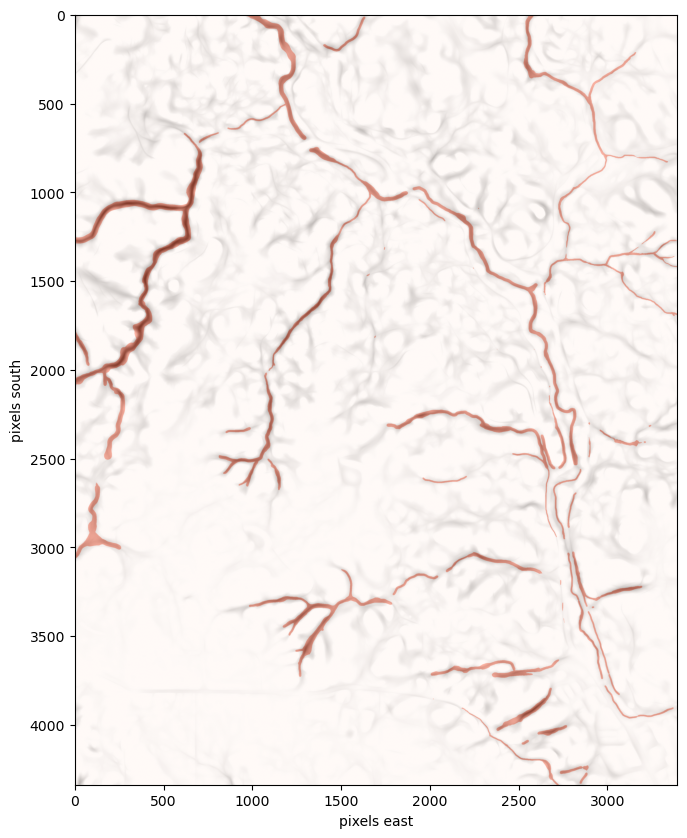

In [18]:
fig, ax = plt.subplots(figsize=(15, 10))

ax.imshow(np.min(convolution15, axis=0), vmax=0, cmap="gray")

ax.imshow(hand_labeled > 0.5, cmap="Reds", vmin=0, vmax=2, alpha=0.5)

ax.set_xlabel("pixels east")
ax.set_ylabel("pixels south")

None

Here is a distribution of the intensity of label. I used paintbrush opacity to indicate regions I wasn't sure were real gullies.

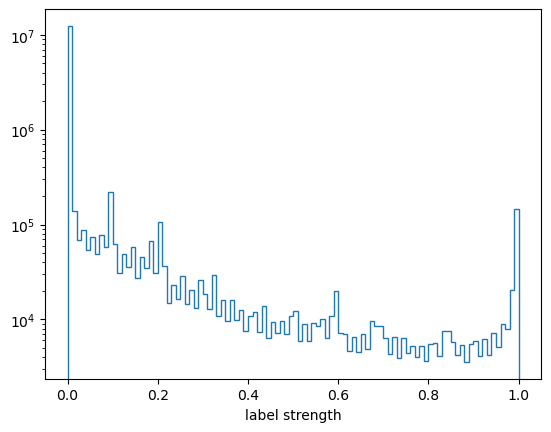

In [19]:
fig, ax = plt.subplots()

ax.hist(hand_labeled.flatten(), bins=100, range=(0, 1), histtype="step")

ax.set_yscale("log")
ax.set_xlabel("label strength")

None

Since these are not hard labels (there are intensities between 0 and 1), I can't use Scikit-Learn's `LogisticRegression` out-of-the-box. However, I can invert the sigmoid function (a logit function), taking care to avoid infinities at the endpoints and do a `LinearRegression` to that.

In [20]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def logit(x):
    return np.log(x / (1 - x))

def shrink(x):
    return x * (1 - 2e-4) + 1e-4

def grow(x):
    return (x - 1e-4) / (1 - 2e-4)

Here is a distribution of the target values for the linear regression.

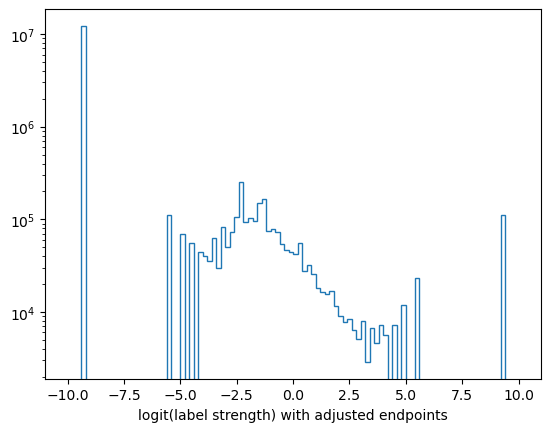

In [21]:
fig, ax = plt.subplots()

ax.hist(logit(shrink(hand_labeled)).flatten(), bins=100, range=(-10, 10), histtype="step")

ax.set_yscale("log")
ax.set_xlabel("logit(label strength) with adjusted endpoints")

None

Here is a round-trip through this transformation to verify that there aren't any errors (larger than floating-point precision).

In [22]:
abs(grow(sigmoid(logit(shrink(hand_labeled)))) - hand_labeled).max()

np.float64(2.220446049250313e-16)

<br><br><br><br><br>

# Characterizing the convolutions as a function of angle

Our set of 16 convolution kernels sample the local terrain under the assumption that a trough is pointing in one of those 16 directions. In a gully, they should have a $\sin(2\theta)$ dependence on angle $\theta$ that is minimized when the convolution kernel is aligned with the direction of the gully. (The factor of $2$ comes from the fact that alignment and anti-alignment have the same response: the kernels are flat-bottomed and do not probe any downward slope, which would be slight, anyway.)

This function was generated by ChatGPT, tested, and cleaned up. (Originally, its purpose was to sample fewer angles when computing the convolution, by putting two-iteration search in the CUDA kernel. However, that would at best speed it up by a factor of 2, and along the way, I discovered how useful this characterization is with all 16 samples.)

In [23]:
SIN_PI_8  = np.sin(np.pi/8)
COS_PI_8  = np.cos(np.pi/8)
SQRT1_2   = np.sqrt(1/2)
INV16 = 1/16
INV8  = 1/8

def best_fit(y0, y1, y2, y3, y4, y5, y6, y7, y8, y9, y10, y11, y12, y13, y14, y15):
    # Constant term is the mean
    A = INV16 * (y0 + y1 + y2 + y3 + y4 + y5 + y6 + y7 + y8 + y9 + y10 + y11 + y12 + y13 + y14 + y15)

    # Sine projection:
    # sin(k*pi/8) over k=0..15 is:
    # [0, s, m, c, 1, c, m, s, 0, -s, -m, -c, -1, -c, -m, -s]
    t_s = (y1 + y7)  - (y9 + y15)    # weights with ±sin(pi/8)
    t_m = (y2 + y6)  - (y10 + y14)   # weights with ±sqrt(1/2)
    t_c = (y3 + y5)  - (y11 + y13)   # weights with ±cos(pi/8)
    t_1 =  y4 - y12                  # weights with ±1
    S_sum = (SIN_PI_8 * t_s) + (SQRT1_2 * t_m) + (COS_PI_8 * t_c) + t_1
    B = INV8 * S_sum

    # Cosine projection:
    # cos(k*pi/8) over k=0..15 is:
    # [1, c, m, s, 0, -s, -m, -c, -1, -c, -m, -s, 0,  s,  m,  c]
    u_1 =  y0 - y8                   # weights with ±1
    u_c = (y1 + y15) - (y7 + y9)     # weights with ±cos(pi/8)
    u_m = (y2 + y14) - (y6 + y10)    # weights with ±sqrt(1/2)
    u_s = (y3 + y13) - (y5 + y11)    # weights with ±sin(pi/8)
    C_sum = u_1 + (COS_PI_8 * u_c) + (SQRT1_2 * u_m) + (SIN_PI_8 * u_s)
    C = INV8 * C_sum

    return A, B, C

The following code block randomly selects a pixel with a strong bias for being in a gully (minimum `convolution15` in 100,000 trials).

If you run it repeatedly, you see that gully pixels have a consistent pattern: sinusodial in convolution kernel angle with a minimum that depends weakly on kernel line length and a maximum that depends strongly on kernel line length.

If you try random pixels (not likely in a gully), the patterns are very different:
* overall, the convolution strength is less negative (which is the basic indicator of a gully)
* sinusodial dependencies have less amplitude
* sinusodial minima are less tightly grouped.

I also noticed that for gully pixels, the minimum convolution strength is often a little lower than the minimum of the sinusodial fit (and the maximum is a little higher than the fit). Thus, many gully pixels have an angular dependence that is a little more pointed than a pure sine. I considered using that (alone) as a gully detector, but it's noisy because the difference, while systematic, is typically less than a meter and other local variations complicate the pattern. However, this observation can contribute to the final fit by extracting observed minimum separately from the fit minimum.

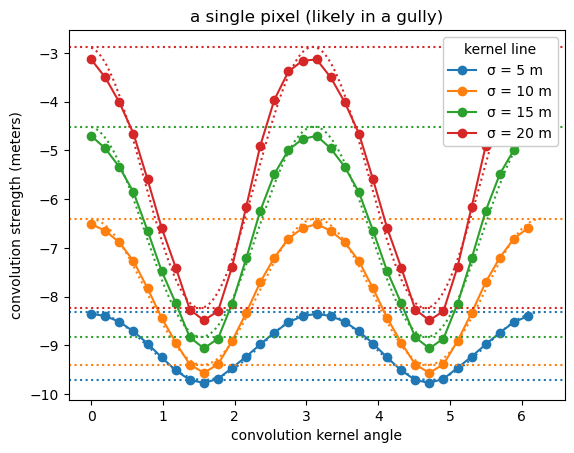

In [24]:
fig, ax = plt.subplots()

_, i, j = sorted([
    (convolution15[:, i, j].min(), i, j)
     for i, j in zip(np.random.randint(0, convolution15.shape[1], 100000), np.random.randint(0, convolution15.shape[2], 100000))
])[0]

# i, j = np.random.randint(0, convolution15.shape[1]), np.random.randint(0, convolution15.shape[2])

def draw(convolution, color, label):
    pixel = convolution[:, i, j]

    x = np.arange(0, 180, 11.25) * np.pi/180
    ax.plot(x.tolist() + (x + np.pi).tolist(), pixel.tolist() * 2, marker="o", color=color, label=label)
    
    A, B, C = best_fit(*pixel)
    x = np.linspace(0, 2*np.pi, 320)
    y = A + B*np.sin(2*x) + C*np.cos(2*x)
    ax.plot(x, y, color=color, ls=":")

    ax.axhline(A - np.sqrt(B**2 + C**2), color=color, ls=":")
    ax.axhline(A + np.sqrt(B**2 + C**2), color=color, ls=":")

draw(convolution5, color=default_colors[0], label="σ = 5 m")
draw(convolution10, color=default_colors[1], label="σ = 10 m")
draw(convolution15, color=default_colors[2], label="σ = 15 m")
draw(convolution20, color=default_colors[3], label="σ = 20 m")

ax.legend(framealpha=1, loc="upper right", title="kernel line")

ax.set_title("a single pixel (likely in a gully)")
ax.set_xlabel("convolution kernel angle")
ax.set_ylabel("convolution strength (meters)")

None

<br><br><br><br><br>

# Engineered features for the fit

I considered all of the observed convolution strengths, minimized and maximized over convolution kernel angle, for each convolution kernel line length.

In [25]:
min5, max5 = np.min(convolution5, axis=0), np.max(convolution5, axis=0)
min10, max10 = np.min(convolution10, axis=0), np.max(convolution10, axis=0)
min15, max15 = np.min(convolution15, axis=0), np.max(convolution15, axis=0)
min20, max20 = np.min(convolution20, axis=0), np.max(convolution20, axis=0)

As well as the minimum and maximum of sinusodial fits, for each convolution kernel line length.

In [26]:
A, B, C = best_fit(*convolution5)
low5, high5 = A - np.sqrt(B**2 + C**2), A + np.sqrt(B**2 + C**2)

In [27]:
A, B, C = best_fit(*convolution10)
low10, high10 = A - np.sqrt(B**2 + C**2), A + np.sqrt(B**2 + C**2)

In [28]:
A, B, C = best_fit(*convolution15)
low15, high15 = A - np.sqrt(B**2 + C**2), A + np.sqrt(B**2 + C**2)

In [29]:
A, B, C = best_fit(*convolution20)
low20, high20 = A - np.sqrt(B**2 + C**2), A + np.sqrt(B**2 + C**2)

In some initial fits with L1 regularization, I saw that the fitter was throwing away all but two line lengths (as expected), so I kept σ = 5 meters and σ = 15 meters (larger than that gets clipped by the size of the kernel).

I also saw that the fitter was throwing away the observed maxima; they don't matter as much as the observed minima.

In addition, the sinusodial maximum is not important on its own, though the amplitude of the sine curve is, so I'll define high-low differences as features, rather than high and low independenly. (Numerical stability of fits.)

Gullies can be found where the minimum is low _and_ the observed minimum is lower than the sinusodial minimum, so bilinear products will be important, since this is how a logical "and" can be computed.

In an earlier version of this notebook, I also tested neural networks with as many as 20 hidden nodes on each of 2 hidden layers, ReLU and Sigmoid, but the results were not noticibly better than this linear fit.

In [30]:
features = ["min5", "min15", "low5", "high5 - low5", "low15", "high15 - low15", "low5 * (high5 - low5)", "low5 * (high15 - low15)", "low15 * (high5 - low5)", "low15 * (high15 - low15)"]

X = np.stack([eval(x) for x in features]).reshape(len(features), -1).T
Y = logit(shrink(hand_labeled)).reshape(-1)

Distributions of these engineered features (which had to be normalized for the neural network; the linear fit can use raw values).

In [31]:
for feature, values in zip(features, X.T):
    print(f"{feature:25s}", np.percentile(values, [0, 25, 50, 75, 100]).tolist())

min5                      [-10.661192893981934, -0.5683707445859909, -0.023607931099832058, 0.48841898143291473, 14.833091735839844]
min15                     [-9.204473495483398, -0.6335967183113098, -0.10882527008652687, 0.23740119487047195, 9.993380546569824]
low5                      [-10.645414934471312, -0.5615313074586732, -0.019799503216258445, 0.49302500696509155, 14.861059899283735]
high5 - low5              [9.732663669437258e-06, 0.04284881314248967, 0.08500959830563021, 0.15595187338988015, 2.730365234058876]
low15                     [-8.934354145506049, -0.6016482884460983, -0.09289931259328393, 0.25357948413996734, 10.048469797088599]
high15 - low15            [2.9200303805265726e-05, 0.15477402967839582, 0.3243409545975747, 0.5751751525992187, 6.029964690147502]
low5 * (high5 - low5)     [-16.080175047329035, -0.04894542922347811, -0.0005053873507183047, 0.03578181416615407, 25.384901016671996]
low5 * (high15 - low15)   [-45.795766050103886, -0.17469827483480216, -0.00

<br><br><br><br><br>

# The linear fit

This is fast because the solver is not iterative (unlike logistic fits and neural networks).

In [32]:
fit = sklearn.linear_model.LinearRegression()
fit.fit(X, Y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Here are the coefficients of each feature (and the bias term).

As expected, `min15` matters most, since the basic gully-finding method would simply be this value.

`low15` is secondary, with an opposite sign: a difference between the observed minimum and the sinusodial minimum is a good indicator of a true gully.

None of these parameters are insignificant (except perhaps `high5 - low5`, the amplitude of the effect of rotating a short linear trough).

In [33]:
for feature, parameter in zip(features, fit.coef_):
    print(f"{feature:25s} {parameter:9.6f}")

min5                       1.349063
min15                     -7.724542
low5                       1.148926
high5 - low5              -0.119572
low15                      3.475965
high15 - low15             1.881988
low5 * (high5 - low5)     -1.023991
low5 * (high15 - low15)   -1.099801
low15 * (high5 - low5)     1.679389
low15 * (high15 - low15)   0.985748


In [51]:
fit.intercept_

np.float64(-9.510743609394627)

<br><br><br><br><br>

# Final gully detection

We'll be using `scipy.ndimage.label` to find connected pixels whose transitive closure are gully objects. A single pixel can connect two gullies or separate them, so we want to apply this algorithm to a raster that is as smooth as possible.

For reasons that we'll see below, I scaled down the image by a factor of 2 (both directions: 4 times fewer pixels) and applied another angle-sensitive convolution to the scaled down image. This is equivalent to the pooling and transformation of a second layer in a Convolutional Neural Network (CNN), except that all of these convolutions are hand-written, rather than learned.

After this pooling and direction-sensitive smoothing, we select all pixels with greater than 5% fit probability and apply `scipy.ndimage.label` to find connected components.

In [34]:
scaled_image = scipy.ndimage.zoom(grow(sigmoid(fit.predict(X))).reshape(hand_labeled.shape), 1/2)

In [35]:
kernel_small = np.stack([line_in_disk(angle, radius=25, linelength=10) for angle in np.arange(0, 180, 11.25)])
scaled_convolved = np.max(convolve2d(scaled_image, kernel_small), axis=0)

In [36]:
all8corners = scipy.ndimage.generate_binary_structure(2, 2)
labeled_image, num_labels = scipy.ndimage.label(scaled_convolved > 0.05, all8corners)

Here are the hand-drawn labels, the fit results, the "second CNN layer" that has been pooled and smoothed, and the final result of the `scipy.ndimage.label` algorithm. Each distinct gully is a different color. Very small objects (fewer than a threshold number of pixels) can be eliminated later.

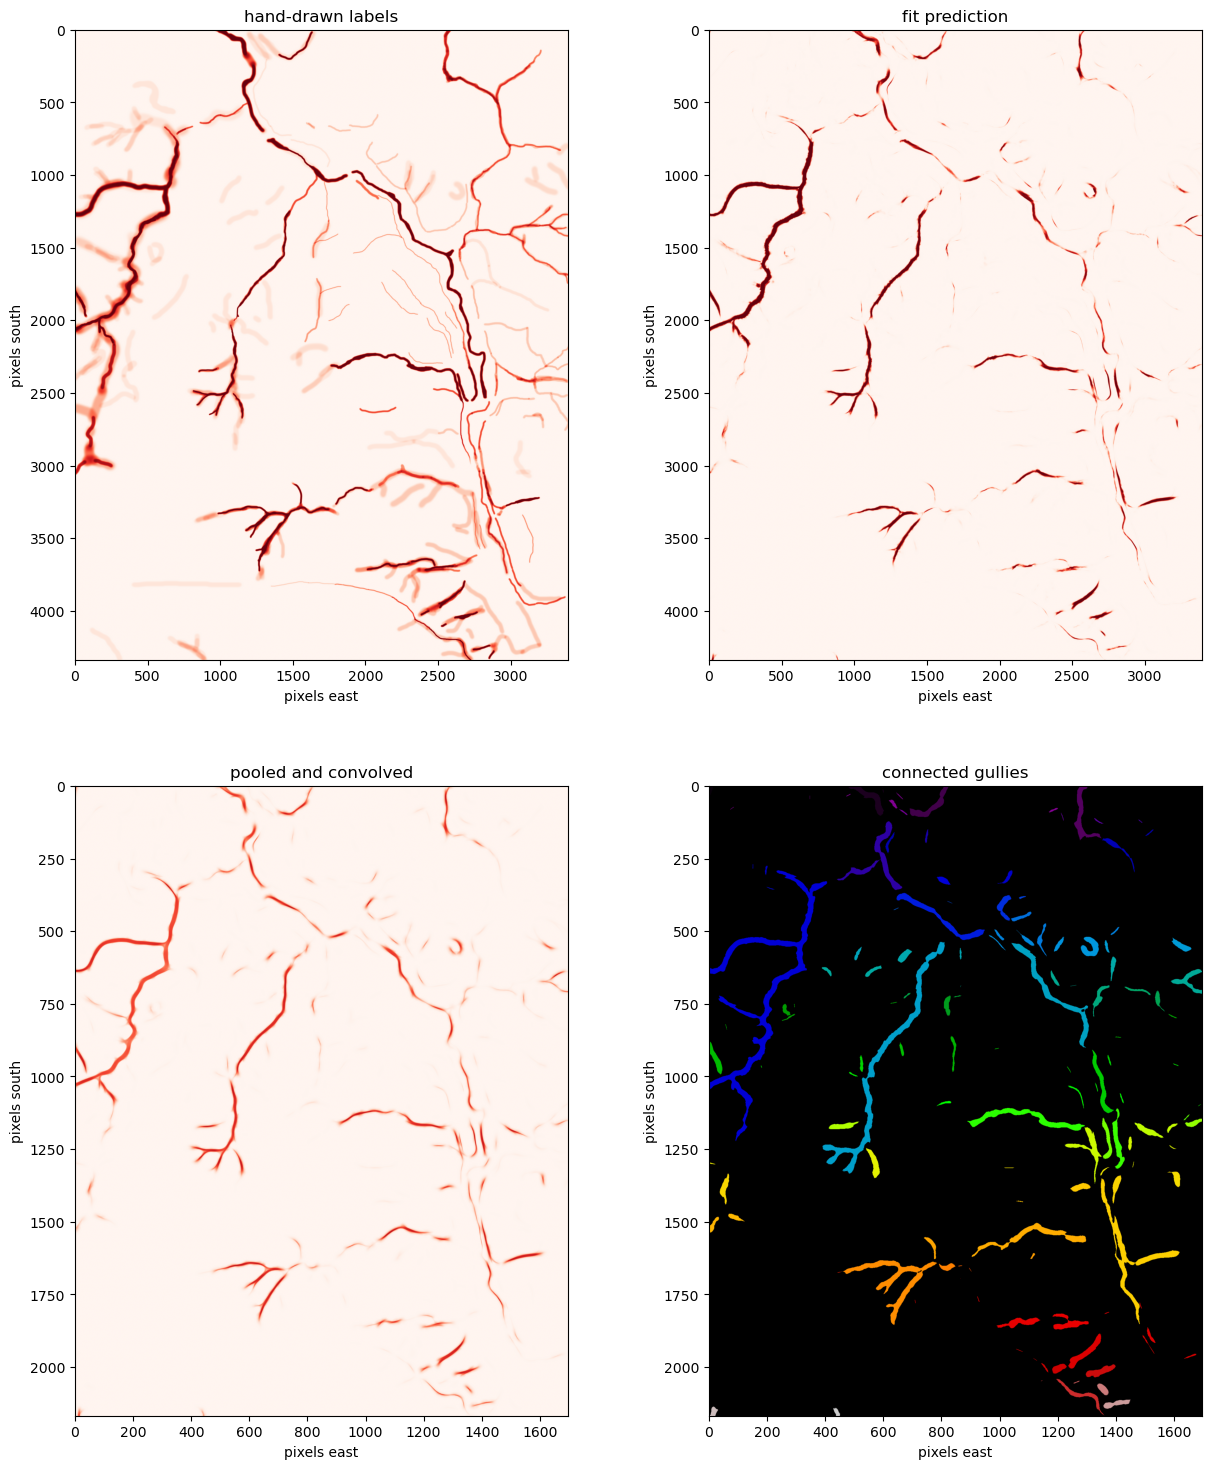

In [37]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 18))

ax1.imshow(hand_labeled, cmap="Reds", vmin=0, vmax=1)
ax1.set_title("hand-drawn labels")

ax2.imshow(grow(sigmoid(fit.predict(X))).reshape(hand_labeled.shape), cmap="Reds", vmin=0, vmax=1)
ax2.set_title("fit prediction")

ax3.imshow(scaled_convolved, cmap="Reds", vmin=0, vmax=1)
ax3.set_title("pooled and convolved")

ax4.imshow(labeled_image, vmin=0, vmax=num_labels, cmap="nipy_spectral")
ax4.set_title("connected gullies")

for ax in (ax1, ax2, ax3, ax4):
    ax.set_xlabel("pixels east")
    ax.set_ylabel("pixels south")

None

Here are the same four images, zoomed into a single gully system to see detail. The output of the fit (applied separately to each pixel) is rough, but the pooling and convolution smooths over the rough edges that might otherwise become tiny disconnected components (or worse, they might disconnect two halves of a large gully).

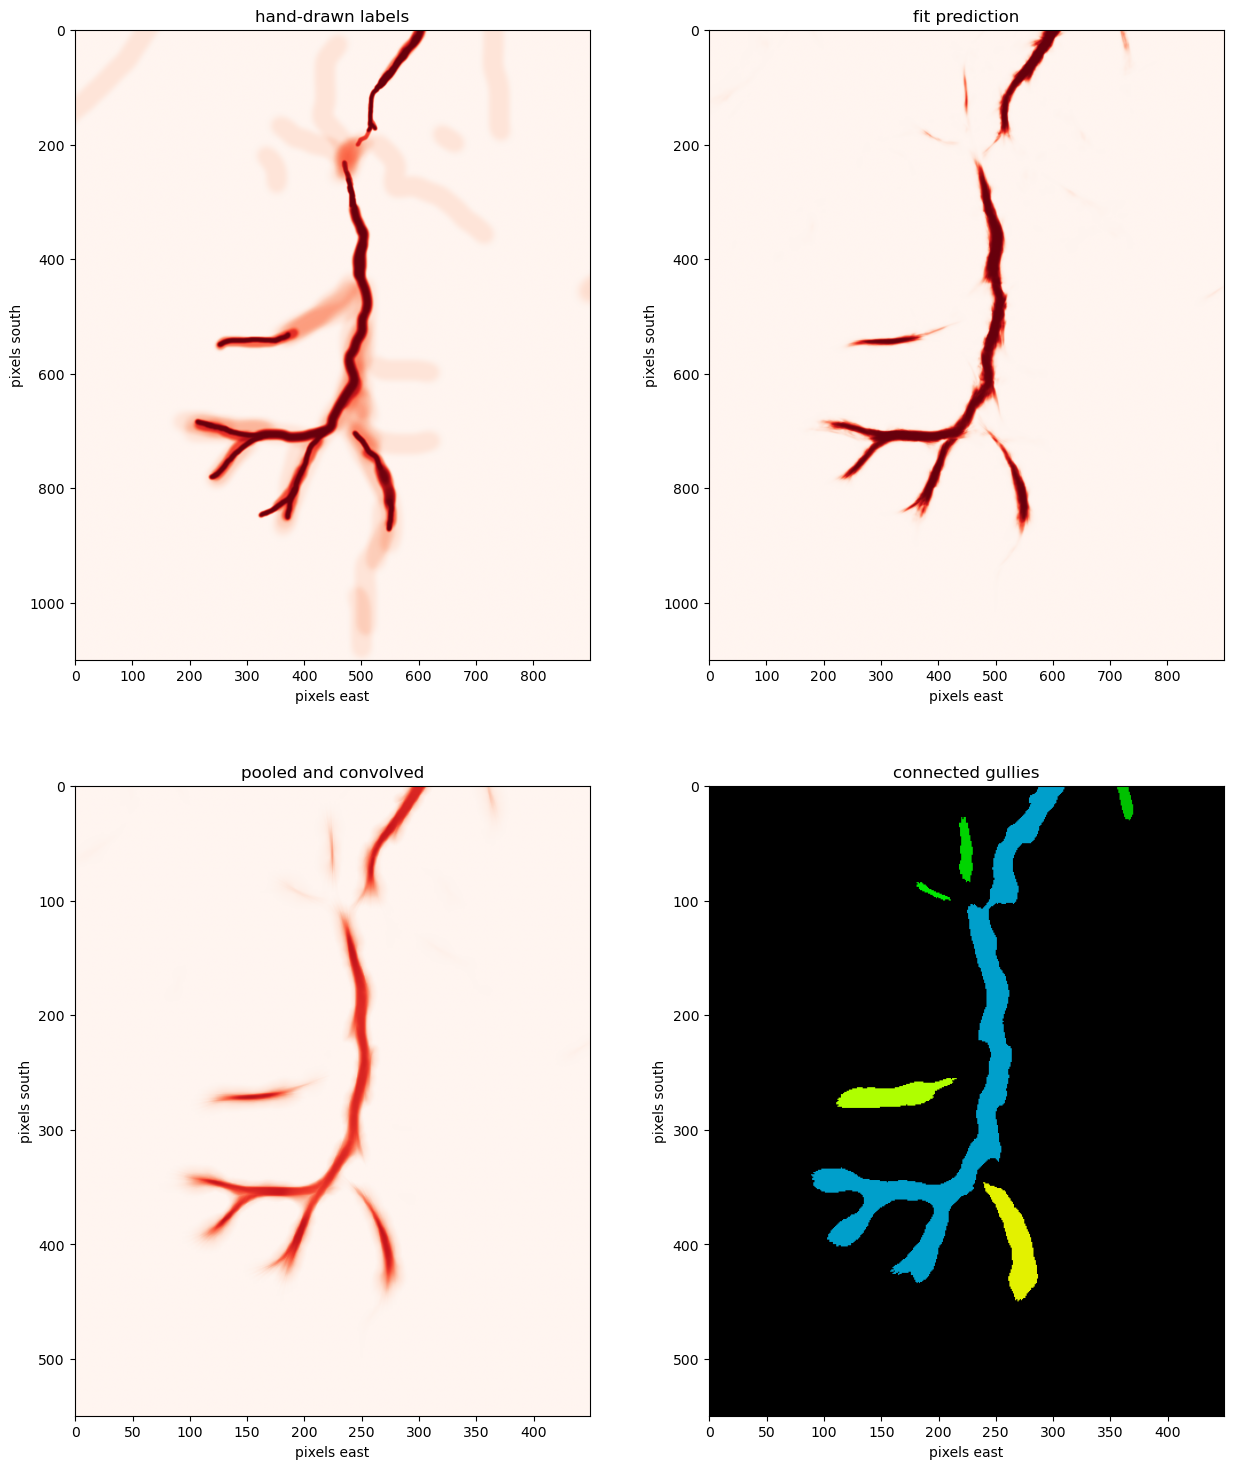

In [38]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 18))

ax1.imshow(hand_labeled[1800:2900, 600:1500], cmap="Reds", vmin=0, vmax=1)
ax1.set_title("hand-drawn labels")

ax2.imshow(grow(sigmoid(fit.predict(X))).reshape(hand_labeled.shape)[1800:2900, 600:1500], cmap="Reds", vmin=0, vmax=1)
ax2.set_title("fit prediction")

ax3.imshow(scaled_convolved[900:1450, 300:750], cmap="Reds", vmin=0, vmax=1)
ax3.set_title("pooled and convolved")

ax4.imshow(labeled_image[900:1450, 300:750], vmin=0, vmax=num_labels, cmap="nipy_spectral")
ax4.set_title("connected gullies")

for ax in (ax1, ax2, ax3, ax4):
    ax.set_xlabel("pixels east")
    ax.set_ylabel("pixels south")

None

<br><br><br><br><br>

# How does this compare with the state-of-the-art?

Was all of this effort worthwhile?

The conventional DFME approach uses the point-in-disk convolution kernel (which doesn't have an angle, but I compute 16 of them anyway because the CUDA kernel expects it).

The image on the left shows local regions of low elevation, and the image on the right has `scipy.ndimage.label` applied with a similar threshold (`-2.5` meters selects approximately as many pixels as `0.05` (5%) in our technique). There are more small islands and the large objects are less-well connected.

We could consider scaling down and convolving again, but this is itself equivalent to a convolutional smoothing, which we've already applied. With only two parameters, the local region radius and central dot size, we can smear structures to connect them or retain fidelity of the shapes, but not both. We fail to take advantage of two facts about gullies:
1. they're long and skinny
2. they're a little deeper in the center than a pure sine curve.

In our new model, we've applied the first fact twice: the sinusodial amplitude (`high15 - low15`) indicates that a depression in the ground has a trough-like orientation, and again when smoothing the scaled-down image, the smoothing prefers to connect blobs that are separated by less than σ = 10 meters. The second fact is new to me, and it adds strength to a puported gully signal, but it's not used exclusively.

In [39]:
point_kernel = np.stack([point_in_disk()] * 16)
point_convolution = convolve2d(elevation, point_kernel)[:, 50:-50, 50:-50]

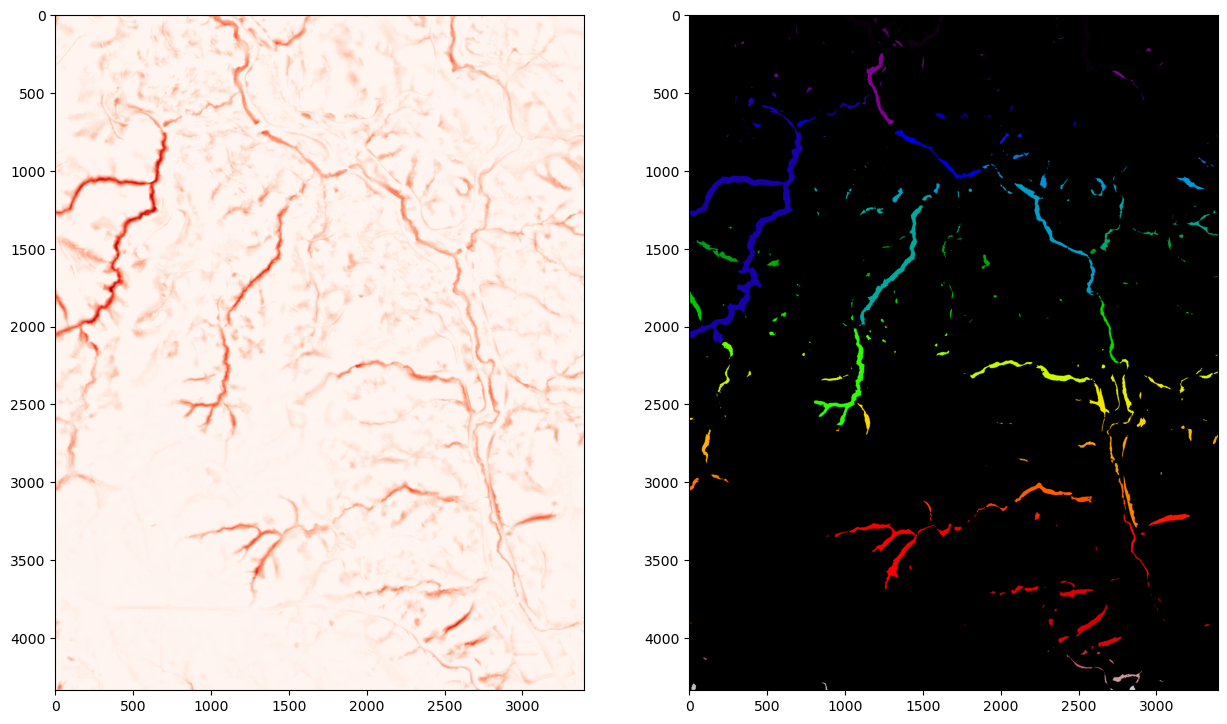

In [50]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 9))

ax1.imshow(np.min(point_convolution, axis=0), cmap="Reds_r", vmax=0)

ax2.imshow(scipy.ndimage.label(np.min(point_convolution, axis=0) < -2.5, all8corners)[0], vmin=0, cmap="nipy_spectral")

None

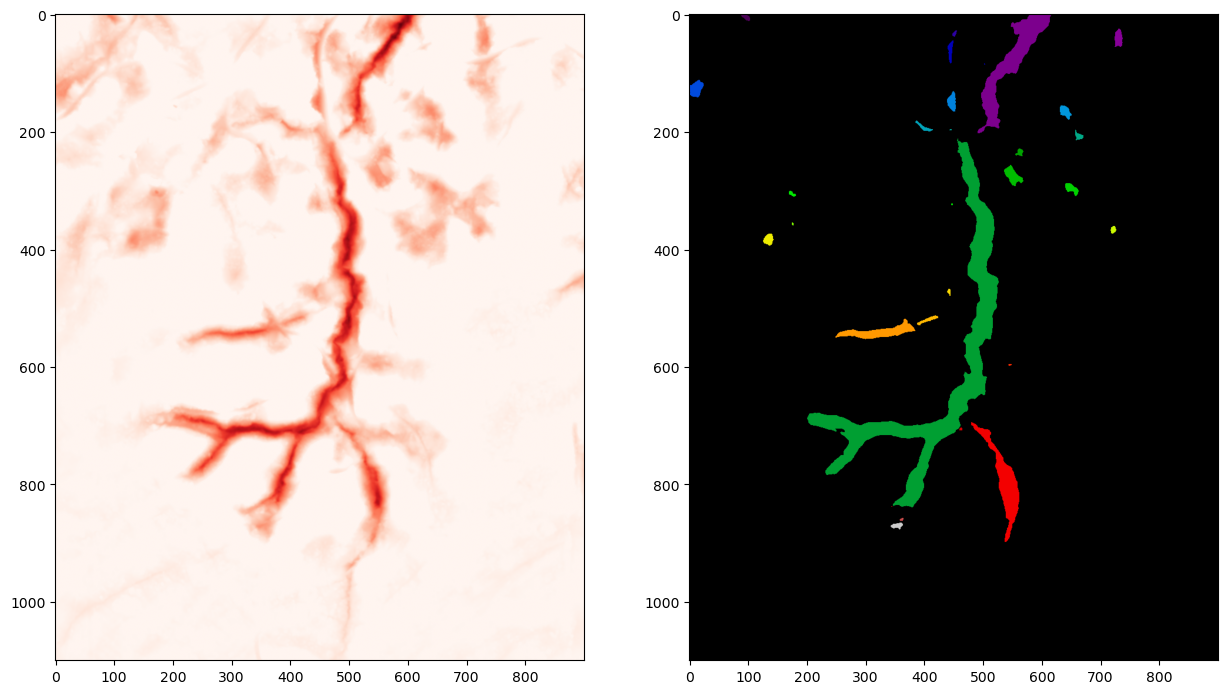

In [49]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 9))

ax1.imshow(np.min(point_convolution, axis=0)[1800:2900, 600:1500], cmap="Reds_r", vmax=0)

ax2.imshow(scipy.ndimage.label(np.min(point_convolution, axis=0)[1800:2900, 600:1500] < -2.5, all8corners)[0], vmin=0, cmap="nipy_spectral")

None

<br><br><br><br><br>

# What will it take to run this at scale?

Each image needs to be convolved with 32 kernels: σ = 5 meters and σ = 15 meters for angles from 0° to (but not including) 180°, separated by 11.25°. 22.5° is not a fine enough resolution to find the observed minimum, and it degrades the fit (`best_fit`, above). This convolution is significantly faster on GPUs. We can take some pressure off of VRAM availability by computing each of the 32 convolutions separately (not all in one CUDA kernel).

The `best_fit` function must be applied to each pack of 16 angular convolutions, and it can use much less memory by implementing it with Numba's `nb.vectorize`.

After preparing each of the engineered features, we only need to compute a linear combination of them:

In [56]:
for feature, parameter in zip(features, fit.coef_):
    print(f"{feature:25s} {parameter}")

print(f"\n{'(intercept)':25s} {fit.intercept_}")

min5                      1.3490627257519279
min15                     -7.724542438400376
low5                      1.1489257918124212
high5 - low5              -0.11957249593352746
low15                     3.475964950455862
high15 - low15            1.8819878621835961
low5 * (high5 - low5)     -1.0239908192101717
low5 * (high15 - low15)   -1.0998012399015833
low15 * (high5 - low5)    1.6793894248166072
low15 * (high15 - low15)  0.9857481489573274

(intercept)               -9.510743609394627


(Much easier than running a neural network!)

Then we need to scale it down by a factor of 2 with `scipy.ndimage.zoom`, apply another set of 16 convolutions to the 4× smaller image with `radius = 25` and `linelength = 10`, and then run `scipy.ndimage.label` to find connected components in the graph. Although there are some small objects that we will want to ignore later, we can defer that decision until we know where to set the threshold.

The test above was performed with a 0.01×0.01 degree square with 4437×3494 pixels.

In [57]:
elevation.shape

(4437, 3494)

The largest watershed file is Blucher Creek (3.3 GB). It has 36964×24494 pixels, which is

In [58]:
(36964 * 24494) / (4437 * 3494)

58.401815198442506

times as many as this example. To do a convolution, we'll need arrays, each with

In [60]:
(36964 * 24494 * 4) / 1024**3

3.3728637397289276

gigabytes, in the GPU's VRAM (the input and the output `float32` arrays; the kernel is tiny). There may be a dozen or so of these arrays in RAM, but that's also not a problem.

On a NVIDIA GeForce RTX 3060, the 0.01×0.01 degree array takes about 60 seconds to compute a pack of 16 angles, so 2 minutes for 16 angles × 2 line lengths. Being 60× larger, we can expect the Blucher Creek array to take 2 hours.

The full dataset consists of 139 files, and the total data size is 45× larger than Blucher Creek. So the longest job will take 2 hours and the total compute time will be 90 hours. At typical cloud GPU prices, that's about &#36;90. It might run on the DSI cluster.

What we'll need to save from each job:
* "fit prediction" raster (same size as input)
* "pooled and convolved" raster (4× smaller than input)
* "connected gullies" integer raster (4× smaller than input and it will compress well)

The input data is 151 GB. The _needed_ outputs would be 5/4 of that, or 190 GB.

What I'd like to also save, just in case it's useful someday (each is an input-sized array):
* `min5`
* `min15`
* `A` for σ = 5 meter line length
* `B` for σ = 5 meter line length
* `C` for σ = 5 meter line length
* `A` for σ = 15 meter line length
* `B` for σ = 15 meter line length
* `C` for σ = 15 meter line length

From these 8 arrays, the 6 features of the fit are constructed by ignoring the angles (two input-sized arrays for σ = 5 and 15 meter line lengths, though only the longer one is significant). The angles are exactly the sort of thing that's likely to be important. I could reduce it to this set:

* `min15`
* `low5`
* `low15`
* `high15 - low15`
* `angles` for σ = 15 meter line length

which is 5 arrays, or even just

* `min15`
* `low15`
* `angles` for σ = 15 meter line length

which is 3 arrays. Only the full set of 8 can compute the "fit prediction" raster, so possible output sizes are
* 8 + 1/4 × input = 1245 GB
* 5 + 1 + 1/4 × input = 945 GB
* 3 + 1 + 1/4 × input = 640 GB

Is half a TB worth 90 hours of compute? I think it is, since I have 8.9 unused TB on the cluster.

Note that if I do this on AWS, it will be about &#36;90 to compute and &#36;112 (&#36;0.09 × 1245 GB) to download the results. The data export is larger than the compute: we'd want to keep it in S3 in separate files that can be downloaded on demand.

Also note that I'll be slicing the output with a watershed-sized mask, which will make large parts of the output arrays more compressible, so the output size could be a factor of two or so smaller than these predictions.